In [1]:
import numpy as np
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten
from keras import backend as k
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
img_rows, img_cols = 28, 28
if k.image_data_format() == 'channels_first':
 x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
 x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
 inpx = (1, img_rows, img_cols)
else:
 x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
 x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
 inpx = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
# Build the model
inpx = Input(shape = inpx)
layer1 = Conv2D(32, kernel_size = (3, 3), activation = 'relu')(inpx)
layer2 = Conv2D(64, (3, 3), activation = 'relu')(layer1)
layer3 = MaxPooling2D(pool_size = (3,3))(layer2)
layer4 = Dropout(0.5)(layer3)
layer5 = Flatten()(layer4)
layer6 = Dense(250, activation = 'sigmoid')(layer5)
layer7 = Dense(10, activation = 'softmax')(layer6)

In [4]:
model = Model([inpx], layer7)
model.compile(optimizer = keras.optimizers.Adadelta(),
 loss = keras.losses.categorical_crossentropy,
 metrics = ['accuracy'])
model.fit(x_train, y_train, epochs = 12, batch_size = 500)

Epoch 1/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 24s 185ms/step - accuracy: 0.0993 - loss: 2.4602
Epoch 2/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.0993 - loss: 2.4460
Epoch 3/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.0993 - loss: 2.4321
Epoch 4/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.0993 - loss: 2.4185
Epoch 5/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.0993 - loss: 2.4054
Epoch 6/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.0993 - loss: 2.3925
Epoch 7/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.0993 - loss: 2.3806
Epoch 8/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.0993 - loss: 2.3687
Epoch 9/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.0993 - loss: 2.3573
Epoch 10/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.0993 - loss: 2.3463
Epoch 11/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - accuracy: 0.0995 - loss: 2.3361
Epoch 12/12
120/120

In [5]:
score = model.evaluate(x_test, y_test, verbose = 0)
print('loss = ', score[0])
print('accuracy = ', score[1])

loss =  2.4683101177215576
accuracy =  0.1527000069618225


In [6]:
y_predicted_by_model = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [7]:
y_predicted_by_model[0]

array([0.03249765, 0.01446952, 0.0320141 , 0.10963947, 0.01238986,
       0.26249894, 0.09470963, 0.27555   , 0.12363784, 0.04259299],
      dtype=float32)

In [8]:
np.argmax(y_predicted_by_model[6])

np.int64(8)

In [9]:
np.argmax(y_test[6])

np.int64(4)

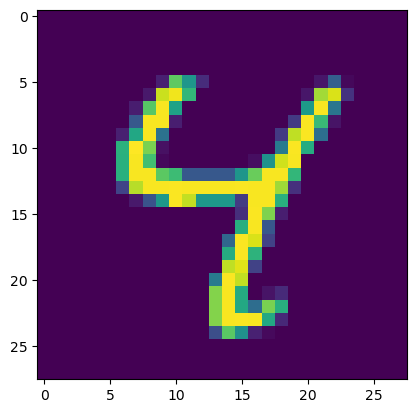

In [10]:
plt.imshow(x_test[6])